<a href="https://colab.research.google.com/github/GaurRitika/P_Folder/blob/main/Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Logistic Regression

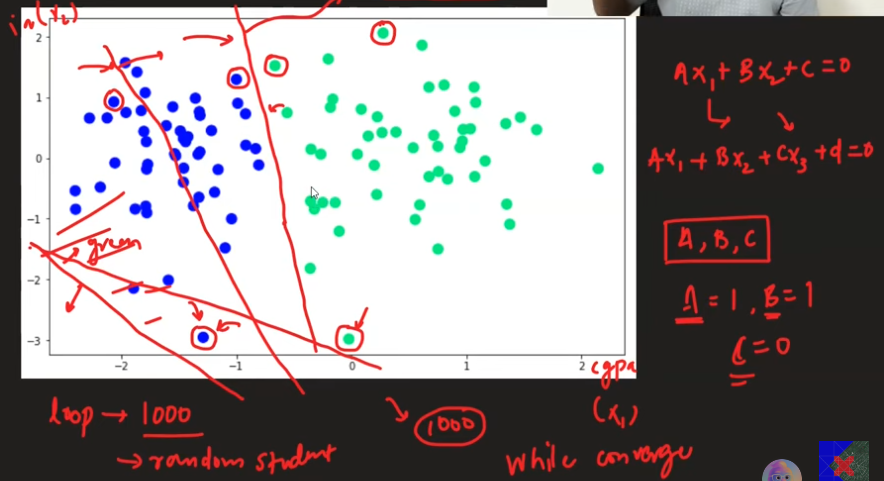

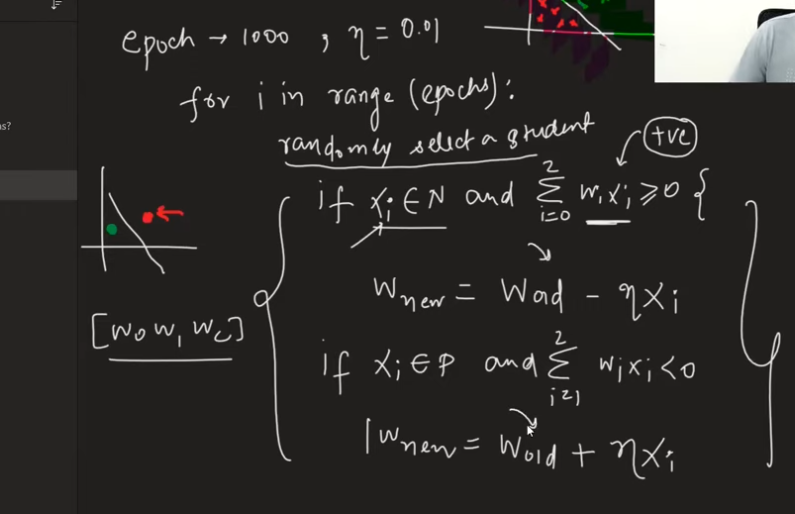

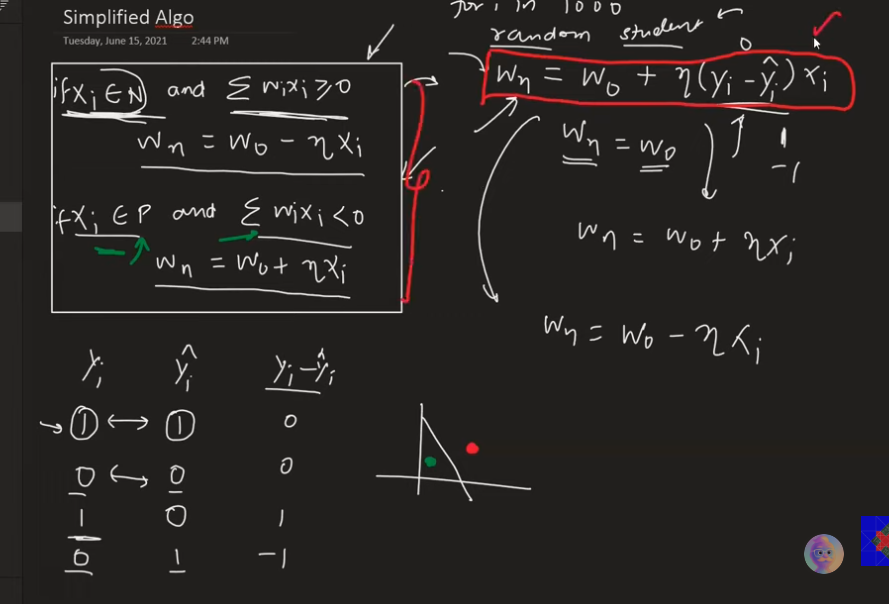

# Logistic Regression — Part 1

## The Perceptron Trick

---

## 1. The Core Problem (Binary Classification)

We have data:

$$
(x_i, y_i), \quad y_i \in {0,1}
$$

Goal:

👉 Separate two classes with a line (or hyperplane)

In 2D:

$$
w^T x + b = 0
$$

This is our **decision boundary**.

Prediction rule (perceptron style):

$$
\hat{y} =
\begin{cases}
1 & \text{if } w^T x + b \ge 0 \
0 & \text{otherwise}
\end{cases}
$$

---

## 2. What Goes Wrong Initially?

Suppose a point is misclassified.

We want to **push the boundary** so the point becomes correct.

This is the heart of the perceptron trick.

---

# 3. The Perceptron Trick — Intuition

Compute the score:

$$
z = w^T x + b
$$

Interpretation:

* ( z > 0 ) → one side of boundary
* ( z < 0 ) → other side
* magnitude → confidence

---

## Case Analysis

### Case 1: Point is positive ((y = 1)) but predicted negative

That means:

$$
w^T x + b < 0
$$

We want to **increase** the score.

✅ Update:

$$
w \leftarrow w + \eta x
$$

$$
b \leftarrow b + \eta
$$

Why?

$$
(w + \eta x)^T x = w^T x + \eta |x|^2
$$

👉 score increases
👉 boundary moves toward correct side

---

### Case 2: Point is negative ((y = 0)) but predicted positive

That means:

$$
w^T x + b \ge 0
$$

We want to **decrease** the score.

✅ Update:

$$
w \leftarrow w - \eta x
$$

$$
b \leftarrow b - \eta
$$

👉 score decreases
👉 boundary shifts back

---

# 4. Compact Perceptron Update Rule

We usually convert labels to:

$$
y \in {-1, +1}
$$

Now the rule becomes elegant.

If misclassified:

$$
w \leftarrow w + \eta, y_i x_i
$$

$$
b \leftarrow b + \eta, y_i
$$

---

## 🔥 Why This Works (Important Insight)

Look at the signed score:

$$
y_i (w^T x_i + b)
$$

* positive → correct
* negative → wrong

When wrong:

$$
w_{\text{new}} = w + \eta y_i x_i
$$

New score becomes:

$$
y_i(w_{\text{new}}^T x_i + b)
= y_i(w^T x_i + b) + \eta |x_i|^2
$$

✅ score increases
✅ moves toward correctness

This is the **Perceptron Trick**.

---

# 5. But There Is a Problem (Very Important)

Perceptron gives only:

* hard classification
* no probabilities
* unstable updates
* no smooth learning
* fails when data is not linearly separable

This is exactly why Logistic Regression was introduced.

---

# 6. Bridge to Logistic Regression (Key Insight)

Perceptron uses **hard step function**:

$$
\text{step}(z)
$$

Problem:

❌ not differentiable
❌ no gradient
❌ cannot use smooth optimization

---

## Logistic Regression Idea

Replace step function with **smooth sigmoid**:

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

Now we get:

✅ probability output
✅ differentiable
✅ gradient-based learning
✅ stable updates

This is the mathematical upgrade of perceptron.



In [79]:
# lets generate a dataset

from sklearn.datasets import make_classification
import numpy as np
X , y = make_classification(n_samples = 100 , n_features = 2 , n_informative = 1 , n_redundant = 0 , n_classes = 2 , n_clusters_per_class = 1, random_state = 41 , hypercube = False , class_sep = 10)

In [80]:
X

array([[ 0.19924745, -0.11697552],
       [-0.24882029, -0.73115232],
       [-0.3544904 , -0.7081059 ],
       [-1.59086506, -2.01199214],
       [-0.20083951,  1.63493163],
       [-0.83241122,  0.15599044],
       [-1.79207014,  1.07782053],
       [ 0.0856607 ,  0.80626713],
       [-0.55865299,  0.74859527],
       [-1.95974262,  0.75152794],
       [-1.77828947, -0.90114581],
       [-1.77985853, -0.1815243 ],
       [-0.02194151, -2.98092432],
       [ 0.80563431,  1.20500136],
       [-1.82701214,  0.78302407],
       [ 0.38730728,  0.42968688],
       [-0.14108668, -0.73229726],
       [-1.87955941, -0.83930476],
       [-0.18232911,  0.83727062],
       [-1.77059533, -0.10255323],
       [-2.27658028,  0.65867001],
       [-2.06519502,  0.92649819],
       [-1.31690551,  0.10216193],
       [ 1.61043259,  0.46886454],
       [-1.21650394,  0.45432938],
       [ 0.6139723 ,  1.8613386 ],
       [-1.78760957, -0.79255991],
       [-1.04149161, -1.0004391 ],
       [-2.40067584,

In [81]:
y

array([1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1,
       0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0,
       1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1])

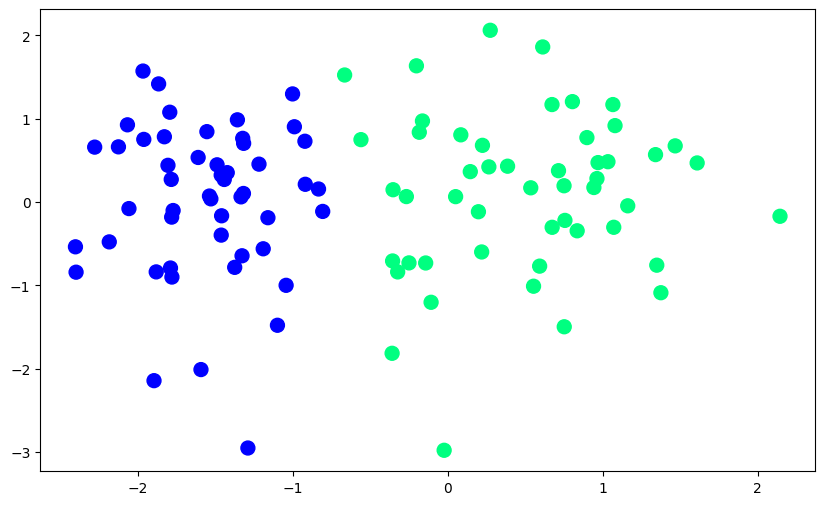

In [82]:
import matplotlib.pyplot as plt
plt.figure(figsize = (10,6))
plt.scatter(X[:,0],X[:,1],c = y , cmap = 'winter' , s = 100)


In [83]:
def perceptron(X , y):
  X = np.insert(X,0,1,axis=1)
  weights= np.ones(X.shape[1])
  lr = 0.1

  for i in range(1000):
    j = np.random.randint(0, 100)
    y_hat = step(np.dot(X[j] , weights))
    weights = weights + lr*(y[j] - y_hat)*X[j]

  return weights[0] , weights[1:]

In [84]:
def step(z):
  return 1 if z>0 else 0

In [85]:
intercept_ , coef_  = perceptron(X , y)

In [86]:
print(coef_)
print(intercept_)

[1.44051093 0.20122819]
0.9


In [87]:
m = -(coef_[0]/coef_[1])
b = -(intercept_/coef_[1])

In [88]:
x_input = np.linspace(X[:,0].min() - 0.5, X[:,0].max() + 0.5, 100)
y_input = m*x_input + b

(-3.0, 2.0)

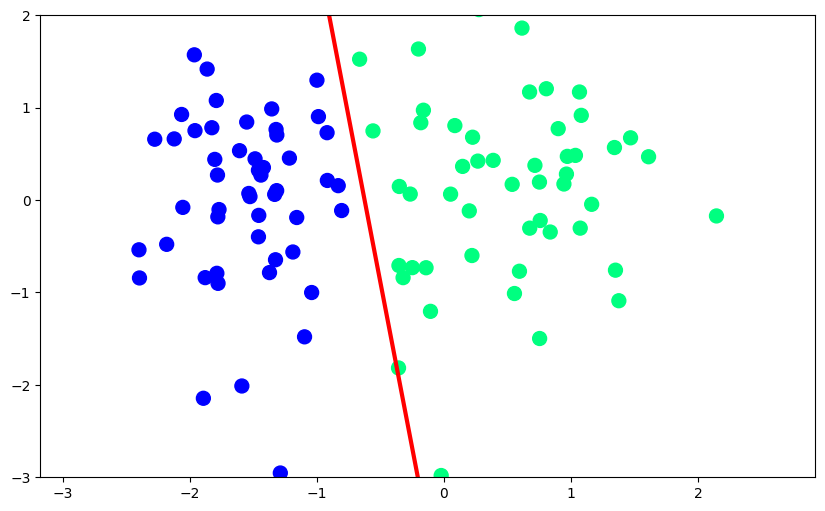

In [89]:
plt.figure(figsize = (10,6))
plt.plot(x_input , y_input , color = 'red' , linewidth=3)
plt.scatter(X[:,0],X[:,1],c = y , cmap = 'winter' , s = 100)
plt.ylim(-3 , 2)

problem with the perceptron trick was .........lets see scikit learn's logistic regression

In [90]:
from sklearn.linear_model import LogisticRegression
lor = LogisticRegression()
lor.fit(X , y)

LogisticRegression()

In [91]:
m = -(lor.coef_[0,0]/lor.coef_[0,1])
b = -(lor.intercept_[0]/lor.coef_[0,1])

In [92]:
x_input1 = np.linspace(X[:,0].min() - 0.5, X[:,0].max() + 0.5, 100)
y_input1 = m*x_input1 + b

(-3.0, 2.0)

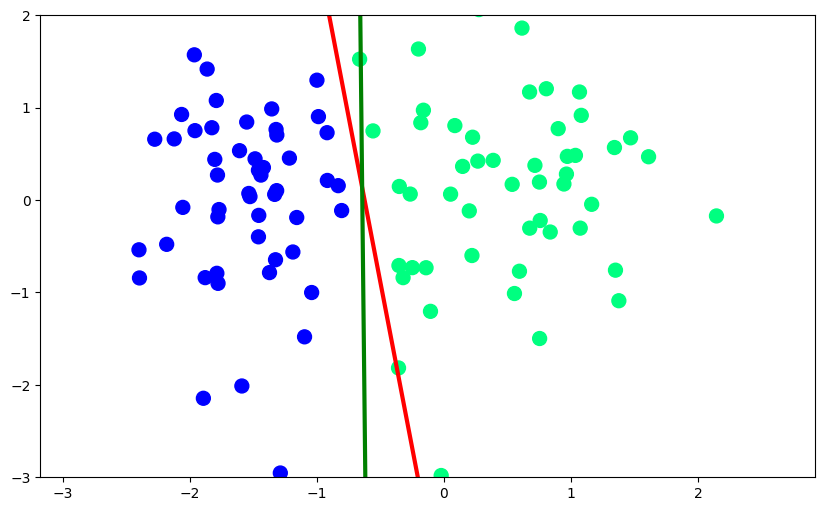

In [93]:
plt.figure(figsize = (10,6))
plt.plot(x_input , y_input , color = 'red' , linewidth=3)
plt.plot(x_input1 , y_input1 , color = 'green' , linewidth=3)
plt.scatter(X[:,0],X[:,1],c = y , cmap = 'winter' , s = 100)
plt.ylim(-3 , 2)

now in perceptron trick it stopped where it jsut classify the classes , it just segregated the points na , but see in logistic it stopped to the maximum extent . means overall it suits well. Has more accuracy and cleanliness..

feel the concept of equilibrium here :)
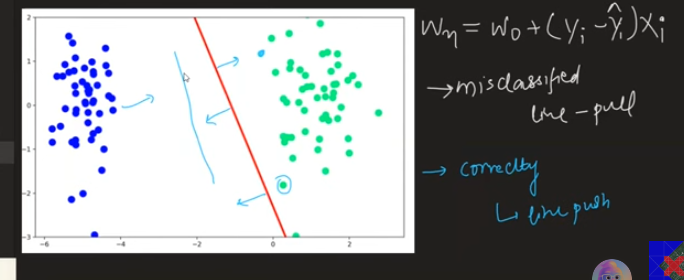

now misclassified points will pull the line , and classified points will push the line . We are doing this to just enhance the perceptron trick's classification.


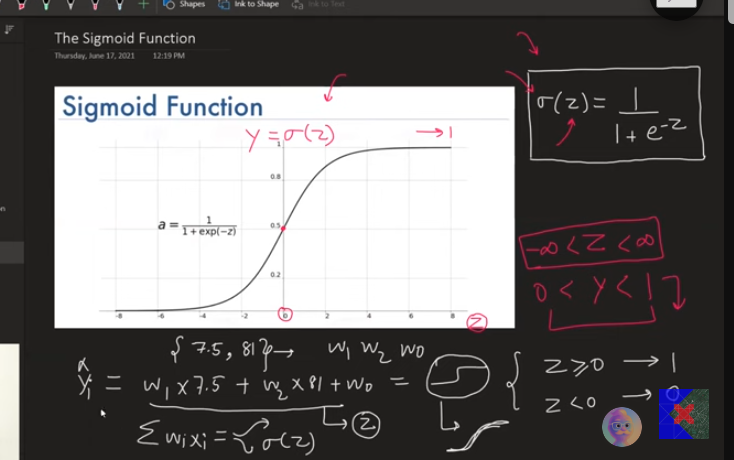


Now hum step function use karte the , in which we got value in  1 or 0 , like z>= 0 , z<=0 . Same sigmawixi ko hum step function meh dene ki jagah sigmoid function meh denge

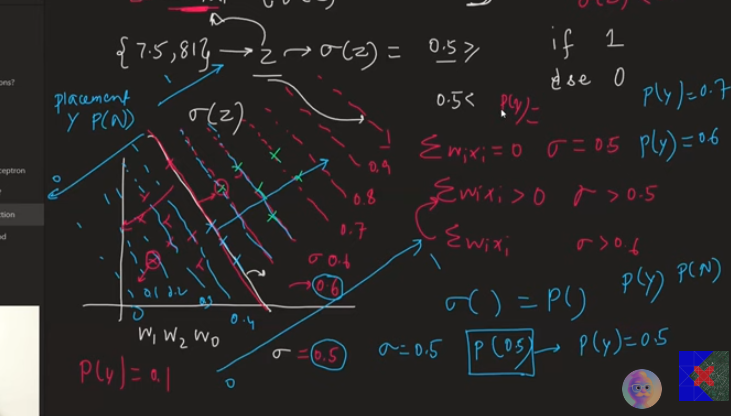

basically we converted everythings in terms of probability , the student who got placed also has certain problability of not neing placed.

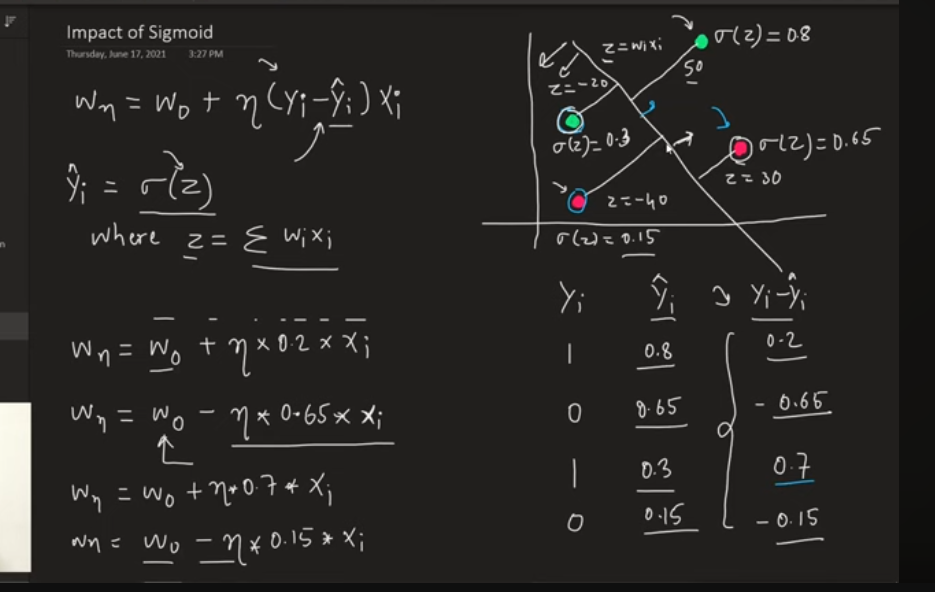

## The Sigmoid Function

---

## 1. Why Do We Need Sigmoid?

From perceptron we had:

$$
z = w^T x + b
$$

Perceptron prediction:

$$
\text{step}(z)
$$

### ❌ Problems

* Not differentiable
* No probability output
* Hard jump at 0
* Not suitable for gradient descent

---

### 🎯 Our Goal

We want a function that:

* takes any real number $z \in (-\infty, \infty)$
* outputs probability in $[0,1]$
* is smooth
* is differentiable

This leads to **sigmoid**.

---

# 2. Definition of Sigmoid

The sigmoid (logistic) function is:

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

where:

$$
z = w^T x + b
$$

So logistic regression predicts:

$$
\hat{p} = P(y=1 \mid x) = \sigma(w^T x + b)
$$

---

# 3. Shape Intuition

Sigmoid is an **S-shaped curve**.

**Key behavior:**

* very negative $z$ → output ≈ 0
* very positive $z$ → output ≈ 1
* near 0 → smooth transition

---

## Important Points

### At $z = 0$

$$
\sigma(0) = \frac{1}{2}
$$

👉 decision boundary
👉 model is uncertain

---

### As $z \to +\infty$

$$
\sigma(z) \to 1
$$

👉 strong confidence for class 1

---

### As $z \to -\infty$

$$
\sigma(z) \to 0
$$

👉 strong confidence for class 0

---

# 4. Why Sigmoid Is Special

Sigmoid is not chosen randomly — it has deep statistical meaning.

---

## 🔥 Log-Odds Interpretation

Sigmoid implies:

$$
\log\left(\frac{p}{1-p}\right) = w^T x + b
$$

This is called **logit**.

👉 Logistic regression assumes **log-odds are linear in features**.

---

# 5. Beautiful Mathematical Property

Derivative of sigmoid:

$$
\sigma'(z) = \sigma(z)\left(1 - \sigma(z)\right)
$$

### 🚀 Why This Matters

* easy gradient computation
* efficient optimization
* stable learning

---

# 6. Decision Rule

We predict:

$$
\hat{y} =
\begin{cases}
1 & \text{if } \sigma(z) \ge 0.5 \\
0 & \text{otherwise}
\end{cases}
$$

Since $\sigma(0) = 0.5$, this is equivalent to:

$$
w^T x + b \ge 0
$$



## Maximum Likelihood: Concept & Derivation

---

# 1. What Are We Really Trying to Do?

We have data:

$$
(x_i, y_i), \quad y_i \in {0,1}
$$

Our model predicts:

$$
p_i = P(y_i=1 \mid x_i) = \sigma(w^T x_i + b)
$$

Now the real question:

> **How do we choose the best $(w, b)$?**

Perceptron used heuristic updates.
Logistic Regression uses **probability theory**.

---

# 2. Maximum Likelihood — Core Idea

### 🎯 Philosophy

Choose parameters that make the observed data **most probable**.

Formally:

$$
\text{Choose } w,b \text{ that maximize } P(\text{data} \mid w,b)
$$

This is called **Maximum Likelihood Estimation (MLE)**.

---

## Intuition

Think like this:

* Model assigns probability to each label
* If model is good → true labels get high probability
* If model is bad → true labels get low probability

We want to **maximize confidence on correct labels**.

---

# 3. Likelihood for One Data Point

For a single example:

$$
p_i = \sigma(z_i), \quad z_i = w^T x_i + b
$$

---

### Case A: $y_i = 1$

$$
P(y_i=1) = p_i
$$

---

### Case B: $y_i = 0$

$$
P(y_i=0) = 1 - p_i
$$

---

## 🎯 Combine Both Cases (Elegant Trick)

We can write both cases in **one formula**:

$$
P(y_i \mid x_i) = p_i^{y_i}(1-p_i)^{1-y_i}
$$

✅ Verify mentally:

If $y_i=1$:

$$
p_i^1(1-p_i)^0 = p_i
$$

If $y_i=0$:

$$
p_i^0(1-p_i)^1 = 1-p_i
$$

Beautiful.

---

# 4. Likelihood of Entire Dataset

Assuming data points are independent:

$$
L(w,b) = \prod_{i=1}^{n} p_i^{y_i}(1-p_i)^{1-y_i}
$$

Goal:

$$
\max_{w,b} L(w,b)
$$

---

# 5. Why We Take Log (VERY IMPORTANT)

Problems with raw likelihood:

* product of many numbers → numerical underflow
* hard to differentiate

Since log is monotonic:

$$
\max L \quad \equiv \quad \max \log L
$$

---

## Log-Likelihood

$$
\ell(w,b) =
\sum_{i=1}^{n}
\left[
y_i \log p_i + (1-y_i)\log(1-p_i)
\right]
$$

⚠️ **This is the core equation of logistic regression.**

---

# 6. From Log-Likelihood to Loss Function

In ML we usually **minimize**, not maximize.

So we take negative:

$$
\text{Loss} = -\ell(w,b)
$$

Final logistic loss (Binary Cross-Entropy):
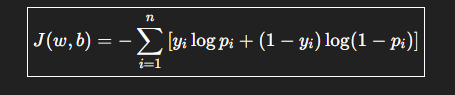

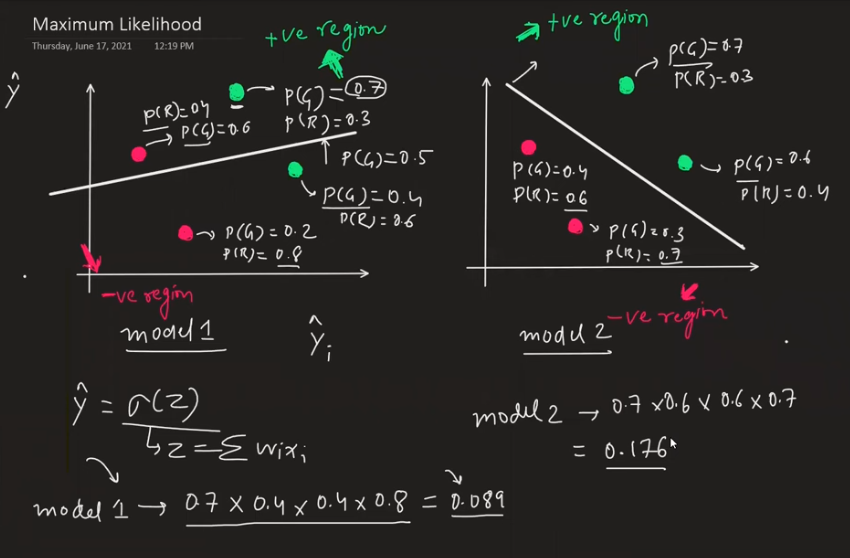


## Gradient of Logistic Loss

---

# 1. Setup (Recall Everything Clearly)

Model:

$$
z_i = w^T x_i + b
$$

$$
p_i = \sigma(z_i) = \frac{1}{1+e^{-z_i}}
$$

Loss (binary cross-entropy):

$$
J(w,b) =
-\sum_{i=1}^{n}
\left[
y_i \log p_i + (1-y_i)\log(1-p_i)
\right]
$$

Goal:

$$
\frac{\partial J}{\partial w}, \quad \frac{\partial J}{\partial b}
$$

---

# 2. Focus on One Data Point First

Always simplify first.

Single-point loss:

$$
L_i = -\left[y_i \log p_i + (1-y_i)\log(1-p_i)\right]
$$

We compute gradient w.r.t. $w$.

---

# 3. Chain Rule Roadmap (VERY IMPORTANT)

Dependency chain:

$$
w \rightarrow z_i \rightarrow p_i \rightarrow L_i
$$

So:

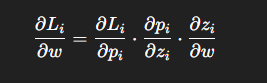


We compute each piece.

---

# 4. Piece 1 — Derivative of Loss w.r.t. $p_i$

From:

$$
L_i = -\left[y_i \log p_i + (1-y_i)\log(1-p_i)\right]
$$

Derivative:

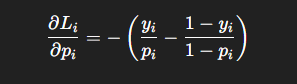


---

# 5. Piece 2 — Sigmoid Derivative (Golden Identity)

You must remember:

$$
\frac{dp_i}{dz_i} = p_i(1-p_i)
$$

---

# 6. Piece 3 — Linear Part

$$
z_i = w^T x_i + b
$$

So:

$$
\frac{\partial z_i}{\partial w} = x_i
$$

---

# 7. Multiply Everything (Magic Happens)

Combine:

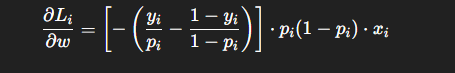

---

## 🔥 Key Simplification

After algebraic simplification:

$$
\boxed{
\frac{\partial L_i}{\partial w} = (p_i - y_i)x_i
}
$$

This is the **famous result**.

---

# 8. Gradient for Entire Dataset

Sum over all points:
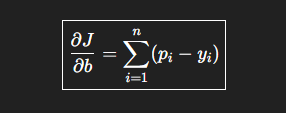
---

# 9. Gradient Descent Update Rule

With learning rate $\eta$:

$$
w \leftarrow w - \eta \sum_{i=1}^{n} (p_i - y_i)x_i
$$

$$
b \leftarrow b - \eta \sum_{i=1}^{n} (p_i - y_i)
$$

---

# 🔥 10. DEEP INSIGHT — Connection to Perceptron

### Perceptron update:

$$
w \leftarrow w + \eta y_i x_i \quad (\text{only if wrong})
$$

---

### Logistic regression update:

$$
w \leftarrow w - \eta (p_i - y_i)x_i
$$

---

## 💡 Interpretation

Term:

$$
(p_i - y_i)
$$

is the **error signal**.

* correct & confident → small update
* wrong & confident → large update
* uncertain → moderate update

✅ smooth learning
✅ stable convergence
✅ probabilistic correction
